In [1]:
from os.path import join
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from PIL import Image
import torch
import matplotlib.pyplot as plt
from scipy.special import comb
from diffusers import StableDiffusionPipeline, DDIMScheduler
from safetensors.torch import load_file
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def get_cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_A = np.linalg.norm(v1)
    norm_B = np.linalg.norm(v2)

    # if norm_A == 0 or norm_B == 0:  # Prevent division by zero
    #     return False  

    cosine_similarity = dot_product / (norm_A * norm_B)
    return cosine_similarity

def latents_to_pil(latents, vae):
    latents = 1 / 0.18215 * latents  # Scale latents back
    image = vae.decode(latents).sample  # Decode latents to pixel space
    image = (image / 2 + 0.5).clamp(0, 1)  # Normalize to [0,1]
    image = (image * 255).byte().cpu().numpy()  # Convert to [0,255] and NumPy
    image = image.transpose(0, 2, 3, 1)  # Rearrange (B, C, H, W) → (B, H, W, C)
    pil_images = [Image.fromarray(img) for img in image]  # Convert to PIL
    return pil_images


In [3]:
from os.path import join
import torch

img_root = '/usr/local/data/zahrat/workshop/dent_output/chexpert-swap-normal/support_devices'

patient_ids = list(range(1500, 3350))

# pe_imgs = {pid: [join(img_root, f'seed{pid}/'normal-pleural_effusion/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(0, 31, 5)] for pid in patient_ids}

sd_img_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}
sd_latent_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.pt')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.pt') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}

sd_latents = {}
for pid, paths in sd_latent_paths.items():
    sd_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for path in paths]
    
# Proof of curvature
patient_infos = []

for pid in tqdm(patient_ids):
    latents_1d_sd = sd_latents[pid]
    cosine_similarities = []
    columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']
    
    for i in range(1, len(latents_1d_sd)):
        v1 = latents_1d_sd[1] - latents_1d_sd[0]
        v2 = latents_1d_sd[i] - latents_1d_sd[0]
        cosine_similarities.append(get_cosine_similarity(v1, v2))
        
    patient_infos.append({
        'pid': pid,
        **dict(zip(columns, cosine_similarities))
    })
        
cosine_similarity_df = pd.DataFrame(patient_infos)
cosine_similarity_df.head()
cosine_similarity_df.to_csv('../metrics/cosine_similarity_sd.csv', index=False)


/tmp/ipykernel_1931268/4261133619.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for 

In [15]:
from os.path import join
import torch

img_root = '/usr/local/data/zahrat/workshop/dent_output/chexpert-swap-normal/pleural_effusion'

patient_ids = list(range(1500, 3392))

pe_img_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}
pe_latent_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.pt')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.pt') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}

pe_latents = {}
for pid, paths in pe_latent_paths.items():
    pe_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for path in paths]
    
# Proof of curvature
patient_infos = []

for pid in tqdm(patient_ids):
    latents_1d_pe = pe_latents[pid]
    cosine_similarities = []
    columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']
    
    for i in range(1, len(latents_1d_pe)):
        v1 = latents_1d_pe[1] - latents_1d_pe[0]
        v2 = latents_1d_pe[i] - latents_1d_pe[0]
        cosine_similarities.append(get_cosine_similarity(v1, v2))
        
    patient_infos.append({
        'pid': pid,
        **dict(zip(columns, cosine_similarities))
    })
        
cosine_similarity_df = pd.DataFrame(patient_infos)
cosine_similarity_df.to_csv('../metrics/cosine_similarity_pe.csv', index=False)


/tmp/ipykernel_1788032/3915186348.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pe_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for 

In [ ]:
from os.path import join
import torch

img_root = '/home/jupyter/dent_outputs/isic2019/melanoma'

patient_ids = list(range(100, 2100))

pe_img_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}
pe_latent_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.pt')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.pt') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}

pe_latents = {}
for pid, paths in pe_latent_paths.items():
    pe_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for path in paths]
    
# Proof of curvature
patient_infos = []

for pid in tqdm(patient_ids):
    latents_1d_pe = pe_latents[pid]
    cosine_similarities = []
    columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']
    
    for i in range(1, len(latents_1d_pe)):
        v1 = latents_1d_pe[1] - latents_1d_pe[0]
        v2 = latents_1d_pe[i] - latents_1d_pe[0]
        cosine_similarities.append(get_cosine_similarity(v1, v2))
        
    patient_infos.append({
        'pid': pid,
        **dict(zip(columns, cosine_similarities))
    })
        
cosine_similarity_df = pd.DataFrame(patient_infos)
cosine_similarity_df.to_csv('../metrics/cosine_similarity_pe.csv', index=False)


# LPIPS for original synthetic images

In [8]:
# Compute LPIPS

import torch
from os.path import join
from tqdm import tqdm
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import lpips

def load_and_preprocess_image(path):
    """Load and preprocess image for LPIPS computation"""
    transform = transforms.Compose([
        transforms.Resize((512, 512)),  # LPIPS expects specific size
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    try:
        img = Image.open(path).convert('RGB')
        return transform(img).unsqueeze(0)
    except Exception as e:
        print(f"Error loading image {path}: {e}")
        return None

# Initialize LPIPS model
loss_fn = lpips.LPIPS(net='alex').cuda()  # Uses AlexNet by default

img_root_path = {
    'support_devices': '/usr/local/data/zahrat/workshop/dent_output/chexpert-swap-normal/support_devices',
    'pleural_effusion': '/usr/local/data/zahrat/workshop/dent_output/chexpert-swap-normal-negative-prompt/pleural_effusion' 
}
for style in ['support_devices', 'pleural_effusion']:
        print(f'Analyzing - {style}')
        img_root = img_root_path[style]
        patient_ids = list(range(1500, 3350))

        # Define image paths
        sd_img_paths = {
            pid: [
                join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')
            ] + [
                join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') 
                for lambda_t_star in range(45, 4, -5)
            ] for pid in patient_ids
        }

        # Compute LPIPS scores
        patient_infos = []
        columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']

        for pid in tqdm(patient_ids):
            try:
                # Load neutral image (reference)
                neutral_path = sd_img_paths[pid][0]
                neutral_img = load_and_preprocess_image(neutral_path)
                
                if neutral_img is None:
                    continue

                neutral_img = neutral_img.cuda()
                lpips_scores = []

                # Compare with each styled image
                for path in sd_img_paths[pid][1:]:  # Skip neutral image
                    styled_img = load_and_preprocess_image(path)
                    
                    if styled_img is None:
                        lpips_scores.append(float('nan'))
                        continue

                    styled_img = styled_img.cuda()
                    
                    with torch.no_grad():
                        distance = loss_fn(neutral_img, styled_img)
                        lpips_scores.append(float(distance.cpu().numpy()))

                patient_infos.append({
                    'pid': pid,
                    **dict(zip(columns, lpips_scores))
                })

            except Exception as e:
                print(f"Error processing patient {pid}: {e}")
                continue

            # Clear CUDA cache periodically
            if len(patient_infos) % 100 == 0:
                torch.cuda.empty_cache()

        # Save results
        lpips_df = pd.DataFrame(patient_infos)
        lpips_df.to_csv(f'../metrics/lpips_{style}.csv', index=False)

        # Clear CUDA cache after each artifact type
        torch.cuda.empty_cache()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code

Loading model from: /usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth
Analyzing - support_devices


100%|██████████| 1850/1850 [06:18<00:00,  4.88it/s]


Analyzing - pleural_effusion


100%|██████████| 1850/1850 [06:57<00:00,  4.43it/s]


In [14]:
pd.read_csv('../metrics/lpips_support_devices.csv').drop(columns=['pid']).mean().mean()

0.051536906328123556

In [15]:
pd.read_csv('../metrics/lpips_pleural_effusion.csv').drop(columns=['pid']).mean().mean()

0.23995978375812907

# LPIPS for interpolations 

In [16]:
# Compute LPIPS

import torch
from os.path import join
from tqdm import tqdm
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import lpips

def load_and_preprocess_image(path):
    """Load and preprocess image for LPIPS computation"""
    transform = transforms.Compose([
        transforms.Resize((512, 512)),  # LPIPS expects specific size
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    try:
        img = Image.open(path).convert('RGB')
        return transform(img).unsqueeze(0)
    except Exception as e:
        print(f"Error loading image {path}: {e}")
        return None

# Initialize LPIPS model
loss_fn = lpips.LPIPS(net='alex').cuda()  # Uses AlexNet by default


for style in ['support_devices', 'pleural_effusion']:
        print(f'Analyzing - {style}')
        img_root = join('/usr/local/data/zahrat/workshop/dent_output/interpolations', style)
        patient_ids = list(range(1500, 2200))

        # Define image paths
        sd_img_paths = {
            pid: [
                join(img_root, f'seed{pid}/bezier_{pid}_{step}.png') 
                for step in range(50)
            ] for pid in patient_ids
        }

        # Compute LPIPS scores
        patient_infos = []
        columns = list(range(50))

        for pid in tqdm(patient_ids):
            try:
                # Load neutral image (reference)
                neutral_path = sd_img_paths[pid][0]
                neutral_img = load_and_preprocess_image(neutral_path)
                
                if neutral_img is None:
                    continue

                neutral_img = neutral_img.cuda()
                lpips_scores = []

                # Compare with each styled image
                for path in sd_img_paths[pid][1:]:  # Skip neutral image
                    styled_img = load_and_preprocess_image(path)
                    
                    if styled_img is None:
                        lpips_scores.append(float('nan'))
                        continue

                    styled_img = styled_img.cuda()
                    
                    with torch.no_grad():
                        distance = loss_fn(neutral_img, styled_img)
                        lpips_scores.append(float(distance.cpu().numpy()))

                patient_infos.append({
                    'pid': pid,
                    **dict(zip(columns, lpips_scores))
                })

            except Exception as e:
                print(f"Error processing patient {pid}: {e}")
                continue

            # Clear CUDA cache periodically
            if len(patient_infos) % 100 == 0:
                torch.cuda.empty_cache()

        # Save results
        lpips_df = pd.DataFrame(patient_infos)
        lpips_df.to_csv(f'../metrics/lpips_{style}_interpolation.csv', index=False)

        # Clear CUDA cache after each artifact type
        torch.cuda.empty_cache()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code

Loading model from: /usr/local/data/zahrat/workshop/dent/venv/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth
Analyzing - support_devices


100%|██████████| 700/700 [06:54<00:00,  1.69it/s]


Analyzing - pleural_effusion


100%|██████████| 700/700 [07:22<00:00,  1.58it/s]


In [17]:
pd.read_csv('../metrics/lpips_support_devices_interpolation.csv').drop(columns=['pid']).mean().mean()

0.04408712512926229

In [18]:
pd.read_csv('../metrics/lpips_pleural_effusion_interpolation.csv').drop(columns=['pid']).mean().mean()

0.2167451777387649

# Interpolation

In [4]:
checkpoint_path = '../saved_models/finetuned_chexpert-sd1.5/checkpoint-9-2500/model.safetensors'
device = 'cuda'

model = StableDiffusionPipeline.from_pretrained(
            'runwayml/stable-diffusion-v1-5',
            safety_checker=None,
            torch_dtype=torch.float16,
            use_safetensors=True,
            low_cpu_mem_usage=True,
        )

if checkpoint_path:
    checkpoint = load_file(checkpoint_path)
    model.unet.load_state_dict(checkpoint)

model = model.to(device)
model.to(device)

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  6.00it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [13]:
img_root

'/usr/local/data/zahrat/workshop/dent_output/chexpert-swap-normal/support_devices'

In [5]:
save_dir = '/usr/local/data/zahrat/workshop/dent_output/interpolations/support_devices'
os.makedirs(save_dir, exist_ok=True)

In [6]:
def bezier_curve(t, points):
    """Computes a Bézier curve interpolation."""
    n = len(points) - 1
    curve = np.zeros_like(points[0])
    
    for i in range(n + 1):
        bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
        curve += bernstein * points[i]
    
    return curve

for pid, latents_1d_sd in tqdm(sd_latents.items()):

    # Example: Using Bézier interpolation for 7 latent vectors
    latent_vectors = latents_1d_sd

    interpolated_vectors = []
    num_steps = 50  # Number of steps along the curve

    for i, t in enumerate(np.linspace(0, 1, num_steps)):
        v = bezier_curve(t, latent_vectors)
        interpolated_vectors.append(v)
        os.makedirs(join(save_dir, f'seed{pid}'), exist_ok=True)
        torch.save(torch.tensor(v).reshape(1, 4, 64, 64), join(save_dir, f'seed{pid}', f'bezier_{pid}_{i}.pt'))
        

    interpolated_vectors = np.array(interpolated_vectors)
    
    # Batching over the interpolated vectors
    interpolated_vectors = interpolated_vectors.reshape((-1, 4, 64, 64))
    
    # batch_size = 10
    # num_batches = len(interpolated_vectors) // batch_size
    # interpolated_vectors = interpolated_vectors[:num_batches * batch_size]
    # interpolated_vectors = interpolated_vectors.reshape(num_batches, batch_size, 4, 64, 64)
    
    # for batch in interpolated_vectors:
    #     images = latents_to_pil(torch.tensor(batch).cuda(), model.vae)
    #     for i, image in enumerate(images):
    #         image.save(join(save_dir, f'seed{pid}', f'bezier_{pid}_{i}.png'))
    
    images = []
    for i in range(len(interpolated_vectors)):
        v = interpolated_vectors[i]
        image = latents_to_pil(torch.tensor(v.reshape((1, 4, 64, 64))).cuda(), model.vae)[0]
        image.save(join(save_dir, f'seed{pid}', f'bezier_{pid}_{i}.png'))
        images.append(image)
        
    # images = images + images[::-1]

    # images[0].save(join(img_root, f'seed{pid}', f'bezier_{pid}.gif'), save_all=True, append_images=images[1:], duration=100, loop=0)

  0%|          | 4/1850 [00:30<3:53:01,  7.57s/it]


KeyboardInterrupt: 

In [117]:
# interpolated_latent = torch.tensor(interpolated_vectors[4].reshape((1, 4, 64, 64))).cuda()


# Concatenate images horizontally
# widths, heights = zip(*(i.size for i in images))
# total_width = sum(widths)
# max_height = max(heights)

# new_im = Image.new('RGB', (total_width, max_height))
# x_offset = 0
# for im in images:
#     new_im.paste(im, (x_offset, 0))
#     x_offset += im.size[0]

# new_im

# Concatenate images as gif


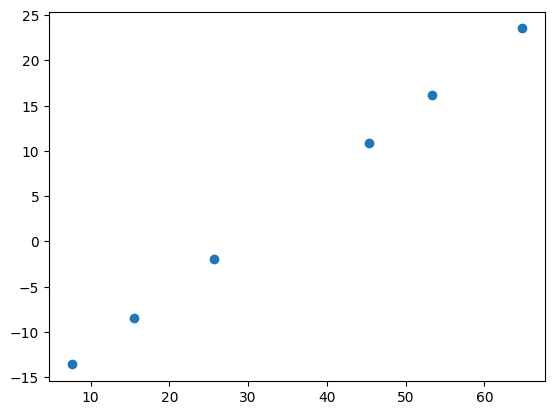

In [89]:
X_interpolated_embedded = TSNE(n_components=2, perplexity=2).fit_transform(latent_vectors)
plt.scatter(X_interpolated_embedded[:, 0], X_interpolated_embedded[:, 1])